# Análisis de Fuga de Talento

## Estrategia ABC Corp

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética
sns.set_theme(style="whitegrid")
df = pd.read_csv('../Base_Datos/df_final.csv')

### 1. ¿TENEMOS REALMENTE UN PROBLEMA?

#### El primer paso es dimensionar la hemorragia de talento. ¿Cuál es la tasa de rotación actual y cómo se distribuye la satisfacción?

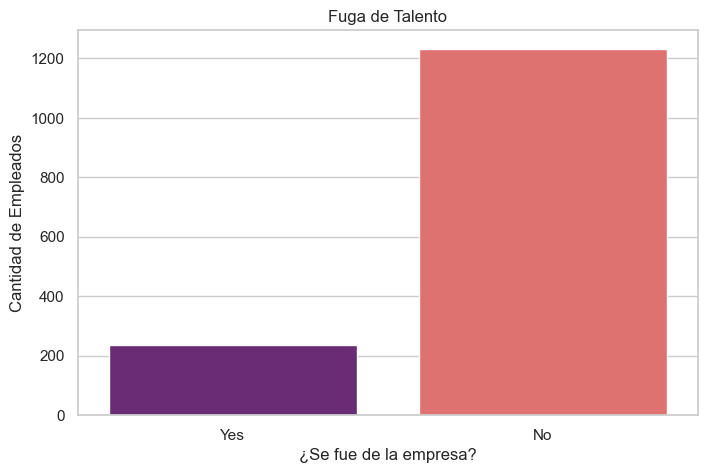

Tasa de Rotación Global: 16.12%


In [16]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Attrition', hue='Attrition', palette='magma', legend=False)
plt.title('Fuga de Talento')
plt.xlabel('¿Se fue de la empresa?')
plt.ylabel('Cantidad de Empleados')
plt.show()

# Cálculo de la tasa
tasa_rotacion = (df['Attrition_flag'].mean() * 100)
print(f"Tasa de Rotación Global: {tasa_rotacion:.2f}%")

Tenemos una tasa de rotación del 16.12%. En una empresa saludable, este número suele rondar el 10%. Esto confirma que sí tenemos un problema. No es una métrica alarmante de crisis total, pero es lo suficientemente alta para erosionar los márgenes operativos y la moral del equipo.

--------------------------

### 2. EL PERFIL DEL RIESGO - ¿QUIÉNES SE VAN?

#### Segmentamos para entender si perdemos experiencia o potencial joven.

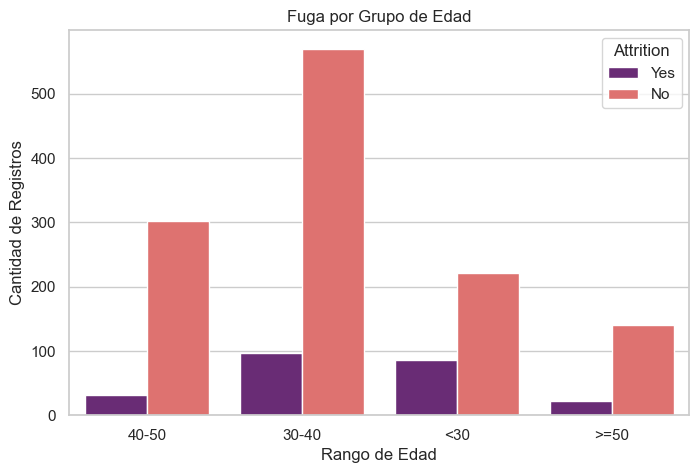

In [38]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='AgeGroup', hue='Attrition', palette='magma')
plt.title('Fuga por Grupo de Edad')
plt.xlabel('Rango de Edad')
plt.ylabel('Cantidad de Registros')
plt.show()

El grupo de menores de 30 años muestra la mayor vulnerabilidad. Mientras que en empleados senior la rotación es baja, en los jóvenes el "Yes" es proporcionalmente mucho más alto. Estamos fallando en retener el talento joven, lo que pone en riesgo el relevo generacional de la empresa.

-------------

### 3. ¿DÓNDE ESTÁ EL INCENDIO? - Departamentos

#### No todas las áreas sufren igual. Identificamos el foco crítico de gestión.

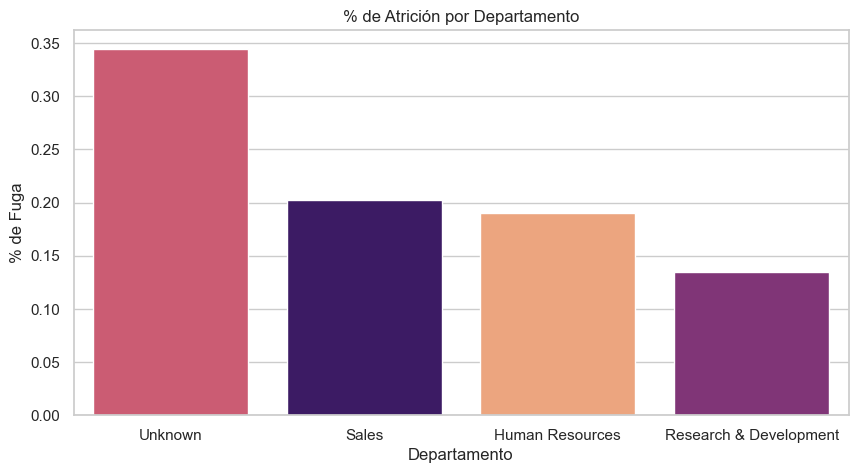

In [39]:
plt.figure(figsize=(10, 5))
dept_order = df.groupby('Department')['Attrition_flag'].mean().sort_values(ascending=False).index
sns.barplot(data=df, x='Department', y='Attrition_flag', order=dept_order, palette='magma', hue='Department', errorbar=None, legend=False)
plt.title('% de Atrición por Departamento')
plt.xlabel('Departamento')
plt.ylabel('% de Fuga')
plt.show()

Ventas es el área crítica. La rotación aquí es significativamente superior a R&D o RRHH. Necesitamos auditar si es la presión por objetivos o un liderazgo agresivo lo que expulsa al personal.

-----------------

### 4. EL IMPACTO DEL ESTADO CIVIL

#### ¿Buscan estabilidad o flexibilidad total?

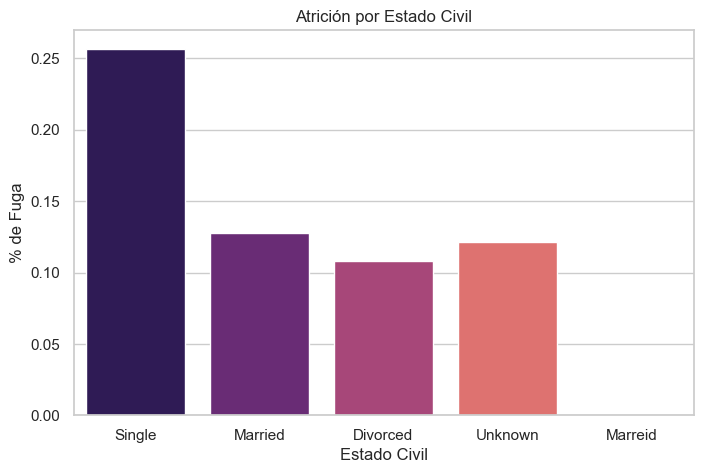

In [41]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='MaritalStatus', y='Attrition_flag', hue='MaritalStatus', palette='magma', errorbar=None, legend=False)
plt.title('Atrición por Estado Civil')
plt.xlabel('Estado Civil')
plt.ylabel('% de Fuga')
plt.show()

Aqui vemos que los solteros se van mas ya que no están atados a responsabilidades familiares pero sí al equilibrio vida-trabajo. Programas de "Social Hub" o flexibilidad, podrian ayudar a una mayor retencion de ese personal.

----------------------

### 5. ¿ES EL TRABAJO O EL ENTORNO?

#### Comparamos la satisfacción con las tareas frente al clima laboral.

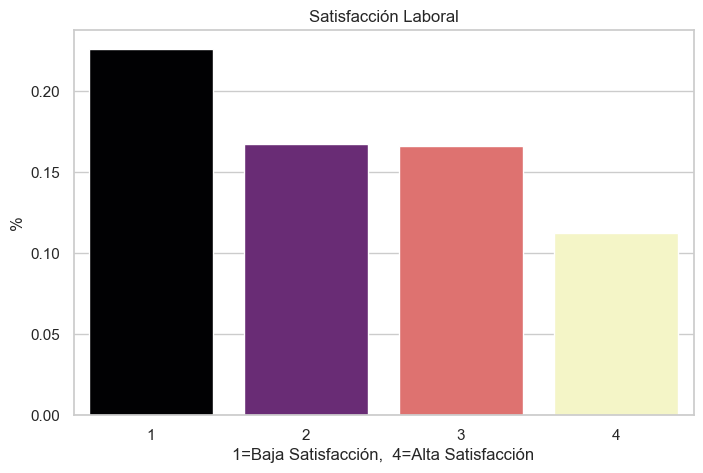

In [12]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='JobSatisfaction', y='Attrition_flag', hue='JobSatisfaction', palette='magma', errorbar=None, legend=False)
plt.title('Satisfacción Laboral')
plt.xlabel('1=Baja Satisfacción,  4=Alta Satisfacción')
plt.ylabel('%')
plt.show(True)

Un empleado "Muy Insatisfecho" tiene el doble de probabilidad de abandonar la empresa que uno "Muy Satisfecho". Sin embargo, incluso en niveles de satisfacción 2 y 3 hay rotación, lo que sugiere que hay factores externos más allá del gusto por el puesto.

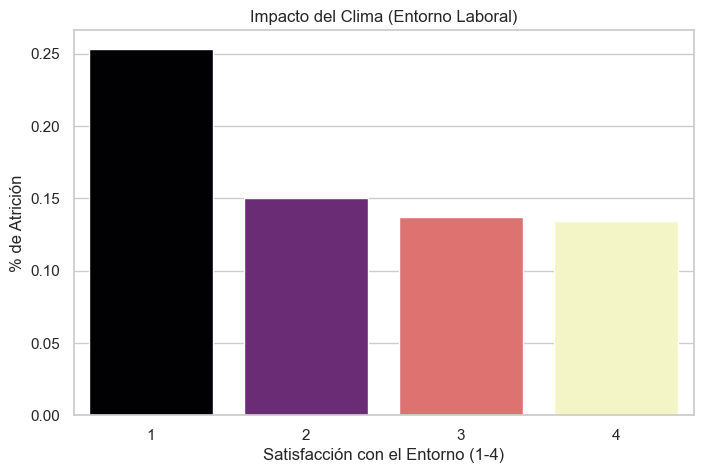

In [40]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='EnvironmentSatisfaction', y='Attrition_flag', hue='EnvironmentSatisfaction', palette='magma', errorbar=None, legend=False)
plt.title('Impacto del Clima (Entorno Laboral)')
plt.xlabel('Satisfacción con el Entorno (1-4)')
plt.ylabel('% de Atrición')
plt.show()

La satisfacción con el entorno físico y cultural es un predictor directo. Quienes califican el entorno con 1 tienen un riesgo de fuga crítico.

-----------

### 6. EQUILIBRIO VIDA-TRABAJO. Factor Decisivo

#### ¿Estamos asfixiando a nuestro talento?

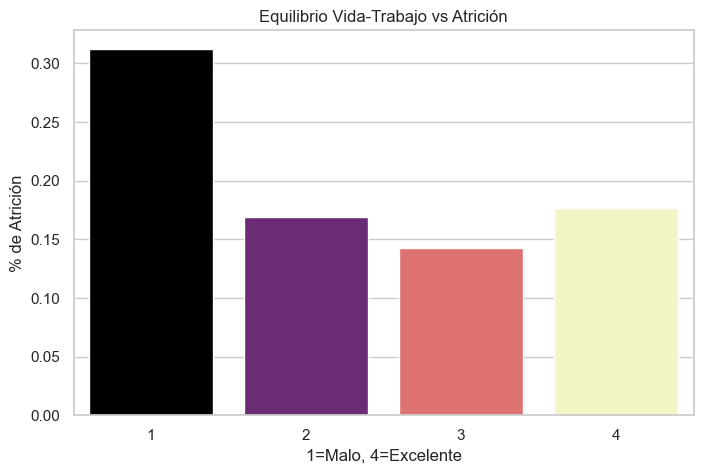

In [45]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='WorkLifeBalance', y='Attrition_flag', hue='WorkLifeBalance', palette='magma', errorbar=None, legend=False)
plt.title('Equilibrio Vida-Trabajo vs Atrición')
plt.xlabel('1=Malo, 4=Excelente')
plt.ylabel('% de Atrición')
plt.show()

Un nivel "Malo" (1) de conciliación dispara la fuga por encima del 30%. La flexibilidad no es un beneficio, es una herramienta de retención esencial y muy necesaria.

-----------

### 7. COMPENSACIÓN Y SENTIDO DE PROPIEDAD

#### ¿Se van por dinero o por falta de incentivos a largo plazo?

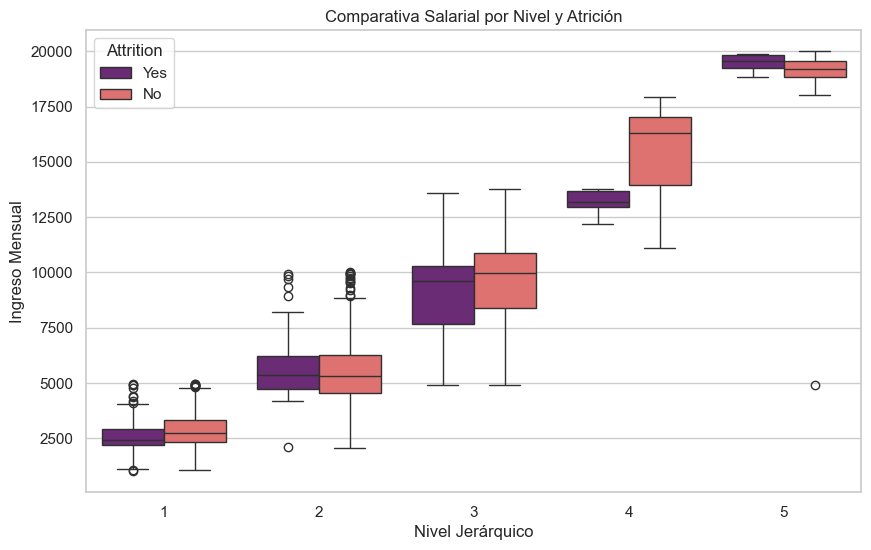

In [43]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='JobLevel', y='MonthlyIncome', hue='Attrition', palette='magma')
plt.title('Comparativa Salarial por Nivel y Atrición')
plt.xlabel('Nivel Jerárquico')
plt.ylabel('Ingreso Mensual')
plt.show()

En el Nivel 1, los empleados que se fueron ganaban significativamente menos que los que decidieron quedarse. Esto indica que en niveles base, la fuga es por mercado: se van por ofertas que pagan ligeramente mejor. En el Nivel 4 también vemos una brecha peligrosa.

#### ¿Se deberian ofrecer mas Stock Options?

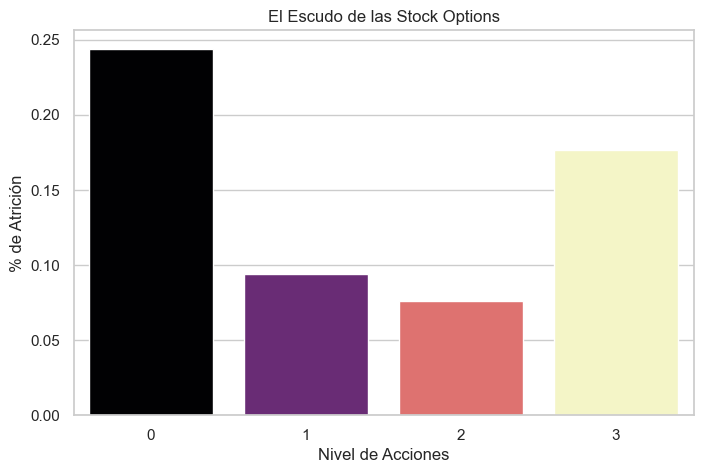

In [46]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='StockOptionLevel', y='Attrition_flag', palette='magma', hue='StockOptionLevel', errorbar=None, legend=False)
plt.title('El Escudo de las Stock Options')
plt.xlabel('Nivel de Acciones')
plt.ylabel('% de Atrición')
plt.show()

Las Stock Options actúan como un candado de lealtad. Darle al empleado una "parte del pastel" reduce la fuga a menos de la mitad.

--------------------------

### 8. ¿LIDERAZGO Y EL CRECIMIENTO?

Evaluamos la relación con el mando medio y las promociones. ¿Cuánto tiempo pasan con su jefe y hace cuánto no tienen un ascenso?

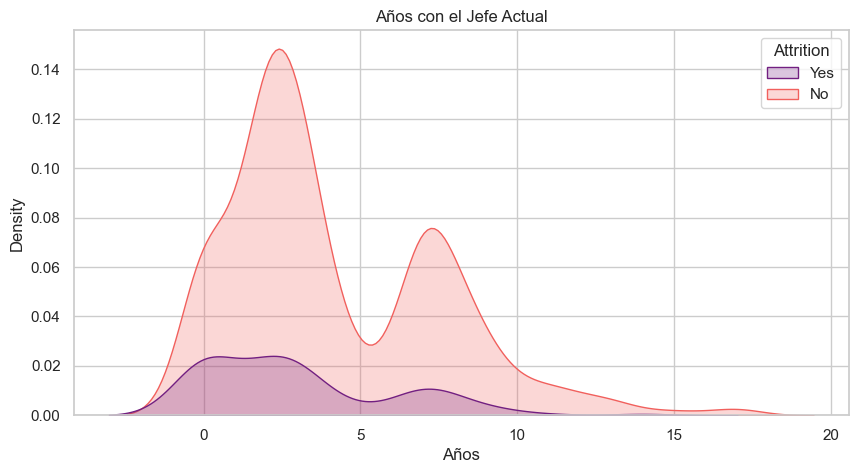

In [32]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='YearsWithCurrManager', hue='Attrition', fill=True, palette='magma')
plt.title('Años con el Jefe Actual')
plt.xlabel('Años')
plt.show()


La fuga tiene un pico alarmante en los primeros 2 años con un nuevo jefe. Es el periodo de adaptación donde se gana o se pierde al empleado para siempre.

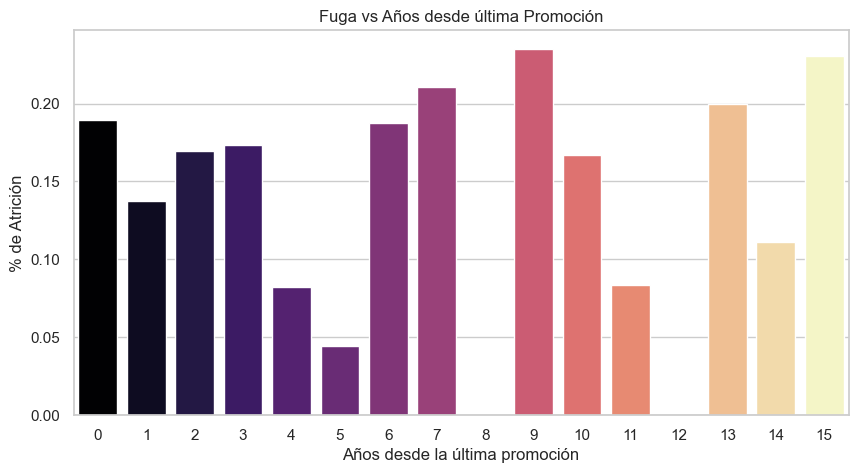

In [31]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='YearsSinceLastPromotion', y='Attrition_flag', hue='YearsSinceLastPromotion', palette='magma', errorbar=None, legend=False)
plt.title('Fuga vs Años desde última Promoción')
plt.xlabel('Años desde la última promoción')
plt.ylabel('% de Atrición')
plt.show()

El estancamiento es real. Al pasar los 7 años sin ascenso, el empleado siente que su carrera en ABC Corp ha terminado y busca horizontes externos

--------------

### 9. ¿EL ENTORNO PERSONAL IMPORTA?

#### Factores externos que impactan la decisión interna. ¿Es la distancia al hogar un factor de riesgo para la rotación?

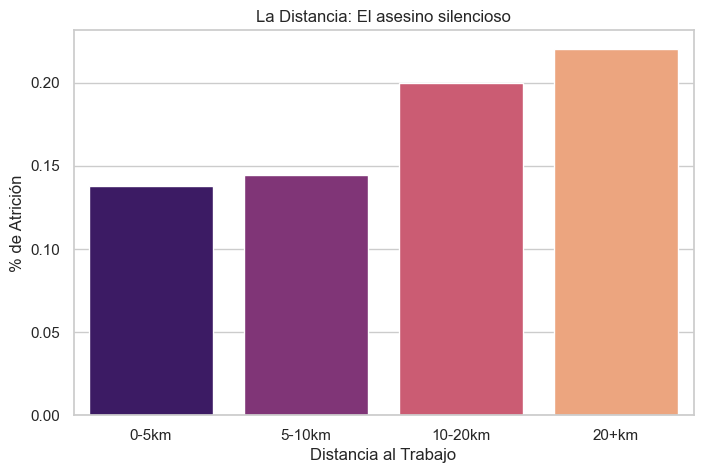

In [47]:
df['Distancia_Cat'] = pd.cut(df['DistanceFromHome'], bins=[0, 5, 10, 20, 100], labels=['0-5km', '5-10km', '10-20km', '20+km'])

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Distancia_Cat', y='Attrition_flag', hue='Distancia_Cat', palette='magma', errorbar=None, legend=False)
plt.title('La Distancia: El asesino silencioso')
plt.xlabel('Distancia al Trabajo')
plt.ylabel('% de Atrición')
plt.show()

A partir de los 10km de distancia, la tasa de salida sube por encima del 20%. Quienes viven a más de 20km son los más propensos a irse. El traslado diario es un factor de desgaste silencioso pero crítico para la retención.

-----------------------

### 10. ¿DÓNDE SE COMBINAN LOS FACTORES DE RIESGO?

#### ¿Dónde está el incendio real? Y ¿Cómo afecta el trabajar Horas Extra (OverTime) a los diferentes grupos de edad?

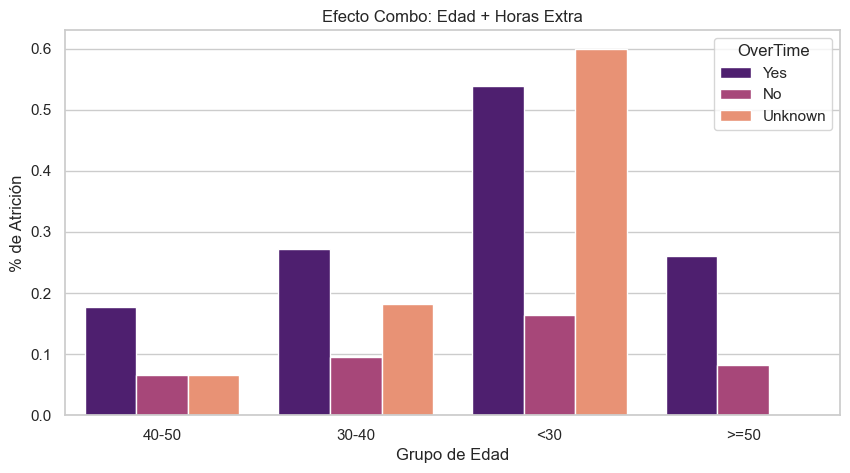

In [19]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='AgeGroup', y='Attrition_flag', hue='OverTime', palette='magma', errorbar=None)
plt.title('Efecto Combo: Edad + Horas Extra')
plt.xlabel('Grupo de Edad')
plt.ylabel('% de Atrición')
plt.show()

Este es el gráfico más revelador. Los jóvenes que hacen horas extra se van de forma masiva. Mientras que los empleados de 40-50 años toleran mejor el OverTime, en el talento joven la probabilidad de fuga se dispara cuando se les exige tiempo adicional.

----------------

### 11. ¿CONTRATAMOS CORRECTAMENTE?

#### Analizamos si el problema viene desde el reclutamiento.

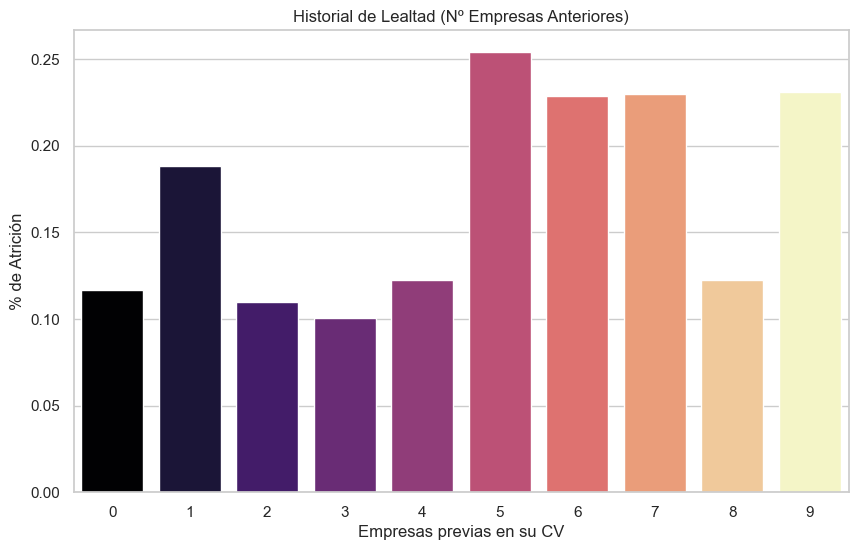

In [48]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='NumCompaniesWorked', y='Attrition_flag', palette='magma', hue='NumCompaniesWorked', errorbar=None, legend=False)
plt.title('Historial de Lealtad (Nº Empresas Anteriores)')
plt.xlabel('Empresas previas en su CV')
plt.ylabel('% de Atrición')
plt.show()

Estamos contratando perfiles "saltamontes". Quienes han pasado por más de 5 empresas tienen una propensión natural a irse. Necesitamos ajustar el filtro de selección.

---------------------

## Diagnóstico Final

ABC Corp sufre una rotación del 16.12%, impulsada principalmente por el departamento de Ventas, empleados jóvenes/solteros y una cultura de exceso de horas extra.

### Plan de Acción Estratégico:

1- Malla Curricular de Liderazgo: Coaching para jefes con menos de 2 años en el puesto para frenar el pico de fuga inicial.

2- Teletrabajo flexible para empleados a más de 15km del centro.

3- Limitar o prohibir el Overtime para el talento menor de 30 años y priorizar descansos sobre pagos extra.

4- Ampliar el acceso a Stock Options de Nivel 1 para perfiles junior críticos, "atándolos" al éxito de la empresa.

5- Priorizar candidatos con historial de estabilidad (menos de 4 empresas previas) para reducir la rotación por inercia.

